# Rayleigh-Bénard convection of a Darcy fluid 

## Create and run the simulation

In [1]:
from functools import partial
import numpy as np
from lucifex.fdm import AB2, CN
from lucifex.sim import run, xdmf_to_npz
from lucifex.plt import (
    plot_colormap, create_animation, plot_line, save_figure, 
    display_animation, get_ipynb_file_name, set_ipynb_variable,
)
from crocodil.dns import dns_darcy_rayleigh_benard

STORE = 1
WRITE = None
DIR_ROOT = f'./figures/{get_ipynb_file_name()}'
DIR_PARAMS = ('Ra', 'Nx', 'Ny')

simulation = dns_darcy_rayleigh_benard(
    store_delta=STORE, 
    write_delta=WRITE, 
    dir_root=DIR_ROOT, 
    dir_params=DIR_PARAMS,
)(
    aspect=2.0,
    Nx=64,
    Ny=64,
    scaling='advective',
    Ra=500.0,
    theta_ampl=1e-3,
    theta_freq=(12, 8), 
    theta_seed=(123, 456), 
    D_adv=AB2, 
    D_diff=CN,
    theta_limits=None,
    theta_stabilization=None,
    diagnostic=True,
)

n_stop = set_ipynb_variable('N_STOP', 500)
dt_init = 1e-6
n_init = 5
run(simulation, n_stop=n_stop, dt_init=dt_init, n_init=n_init)
if WRITE: xdmf_to_npz(simulation, delete_xdmf=False)

theta, u, psi = simulation['theta', 'u', 'psi']
save_fig = partial(save_figure, dir_path=simulation.dir_path, prefix=False)

Environment variable `N_STOP=12`


## Visualization

In [2]:
time_slice = slice(0, None, 2)
titles = [f'$\\theta(t={t:.3f})$' for t in theta.time_series[time_slice]]

anim = create_animation(
    plot_colormap,
    colorbar=False,
)(theta.series[time_slice], title=titles)
anim_path = save_fig(f'{theta.name}(t)', return_path=True)(anim)

display_animation(anim_path)

## Diagnostics

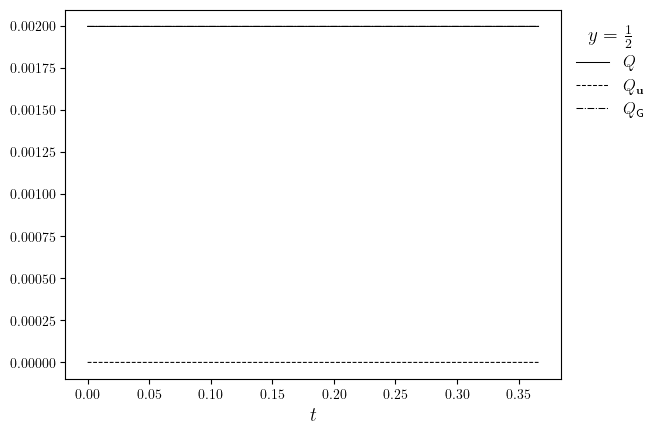

In [3]:
q = simulation['q']
q, qPlus, qMinus = q.split()

fig, ax = plot_line(
    [(q.time_series, [np.sum(i) for i in q.value_series]), (q.time_series, q.value_series)],
    cyc='black',
    x_label='$t$',
    legend_labels=['$Q$', '$Q_{\\mathbf{u}}$', '$Q_{\mathsf{G}}$'],
    legend_title='$y=\\frac{1}{2}$',
)
save_fig('q(t)')(fig)

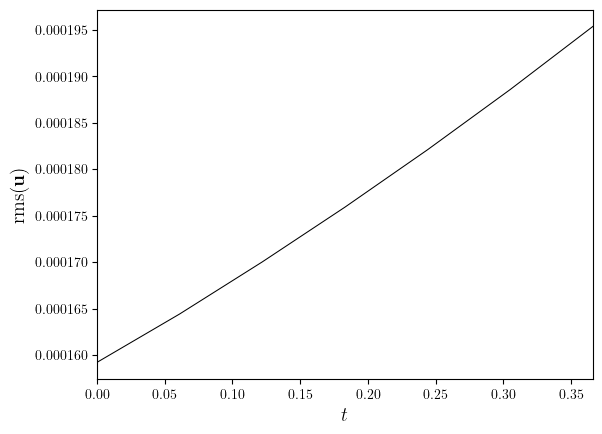

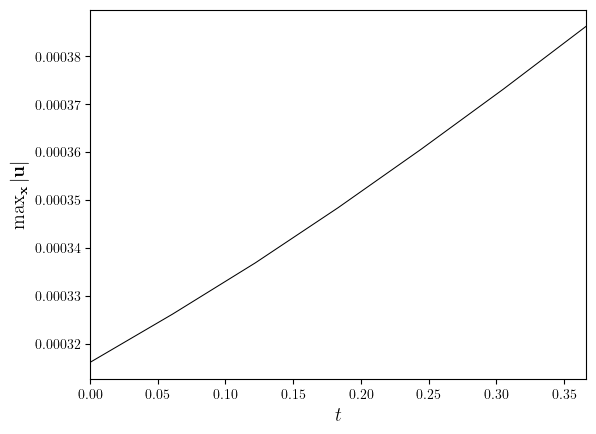

In [4]:
uRMS, uMinMax = simulation['uRMS', 'uMinMax']
uMax = uMinMax.sub(1)

fig, ax = plot_line(
    (uRMS.time_series, uRMS.value_series),
    x_label='$t$',
    y_label='$\mathrm{rms}(\mathbf{u})$',
)
save_fig('uRMS(t)')(fig)

fig, ax = plot_line(
    (uMax.time_series, uMax.value_series),
    x_label='$t$',
    y_label='$\max_{\mathbf{x}}|\mathbf{u}|$',
)
save_fig('uMax(t)')(fig)

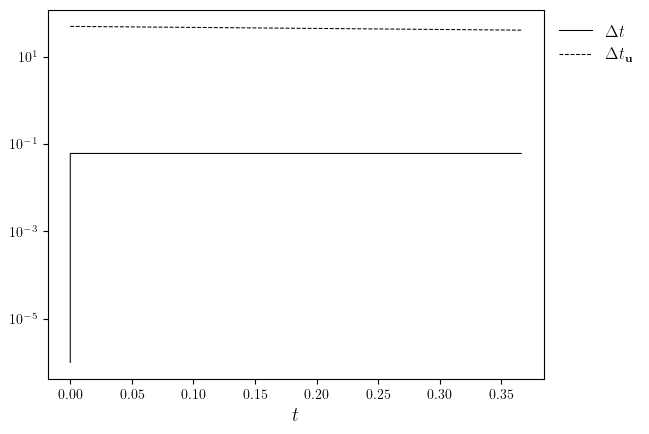

In [5]:
dt, dtCFL = simulation['dt', 'dtU']

fig, ax = plot_line(
    [(dt.time_series, dt.value_series), (dtCFL.time_series, dtCFL.value_series)],
    x_label='$t$',
    legend_labels=['$\Delta t$', '$\Delta t_{\mathbf{u}}$'],
)
ax.set_yscale('log')
save_fig('dt(t)')(fig)

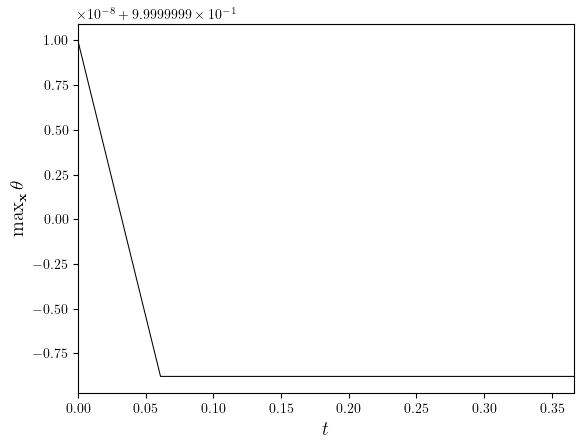

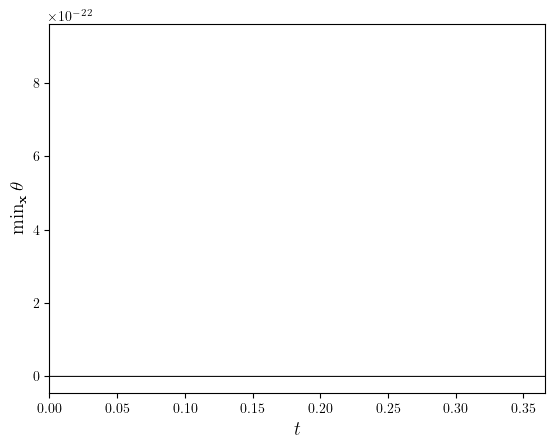

In [6]:
thetaMinMax = simulation['thetaMinMax']
thetaMin, thetaMax = thetaMinMax.split()

fig, ax = plot_line(
    (thetaMax.time_series, thetaMax.value_series),
    x_label='$t$',
    y_label='$\max_{\mathbf{x}}\\theta$',
)
save_fig('thetaMax(t)')(fig)

fig, ax = plot_line(
    (thetaMin.time_series, thetaMin.value_series),
    x_label='$t$',
    y_label='$\min_{\mathbf{x}}\\theta$',
)
save_fig('thetaMin(t)')(fig)